# Pipeline transformaciones

### Equipo Cienciahub

---
Integrantes:
- Sergio Soler
- Joel Montenegro
- Kinan El Halabi

---

## Corpus

**Fuente:** *Amazon Fine Food Reviews* — Stanford Network Analysis Project (SNAP), publicado en Kaggle bajo licencia CC0 (dominio público).


| Característica | Valor |
|---|---|
| Número de reseñas | 568 454 |
| Número de usuarios | 256 059 |
| Número de productos | 74 258 |
| Período cubierto | Octubre 1999 – Octubre 2012 |
| Mediana de palabras por reseña | 56 |
| Volumen aproximado en disco | ~280 MB |
| Idioma | Inglés |
| Licencia | CC0 – Dominio público |

---

## Estructura del conjunto de datos

El corpus consta de **10 columnas**:

| Columna | Descripción | Tipo |
|---|---|---|
| **Id** | Identificador único de cada fila/reseña | entero |
| **ProductId** | Identificador único del producto reseñado | texto |
| **UserId** | Identificador único del usuario que escribió la reseña | texto |
| **ProfileName** | Nombre de perfil del usuario (tiene 26 valores faltantes) | texto |
| **HelpfulnessNumerator** | Cuántos usuarios marcaron la reseña como útil | entero |
| **HelpfulnessDenominator** | Cuántos usuarios en total votaron si la reseña era útil o no (incluye los que dijeron que sí y los que dijeron que no) | entero |
| **Score** | Calificación otorgada por el usuario, de 1 a 5 estrellas | entero |
| **Time** | Marca de tiempo (timestamp) de cuándo se hizo la reseña | entero (Unix timestamp) |
| **Summary** | Resumen breve de la reseña (tiene 27 valores faltantes) | texto |
| **Text** | Contenido completo del texto de la reseña | texto |


---

## Herramientas

| Herramienta | Uso previsto |
|---|---|
| **Pandas** | Carga, manipulación y limpieza del conjunto de datos |
| **NumPy** | Operaciones numéricas y manejo de arreglos |
| **NLTK** | Tokenización, palabras vacías, *stemming* y lematización |
| **Scikit-learn** | Vectorización (BoW, TF-IDF), modelos de clasificación y métricas de evaluación |
| **Matplotlib / Seaborn** | Visualización del análisis exploratorio y de los resultados |

---

## Referencia

McAuley, J. y Leskovec, J. (2013). *From amateurs to connoisseurs: modeling the evolution of user expertise through online reviews*. En *Proceedings of the 22nd International Conference on World Wide Web (WWW '13)*.

Conjunto de datos disponible en: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews

## Carga del dataset y librerias


In [3]:
# Este documento se implemento y ejecuto en Google Colab
import os
import pandas as pd
import numpy as np
import re
import string
import nltk
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter
from kagglehub import KaggleDatasetAdapter
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

PALETA_SENT = {0: "#C0392B", 1: "#1E8449"}
COLOR_BOW = "#2E86C1"
COLOR_TFIDF = "#CA6F1E"

miles = FuncFormatter(lambda x, _: f"{x:,.0f}")
print("Configuración de visualización lista.")

file_path = "Reviews.csv"

df_crudo = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "snap/amazon-fine-food-reviews",
    file_path,
)

Configuración de visualización lista.
Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.


In [4]:
# Calcular el espacio en disco del archivo Reviews.csv
ruta_reviews = '/kaggle/input/amazon-fine-food-reviews/Reviews.csv'

file_size_bytes = os.path.getsize(ruta_reviews)
file_size_kb = file_size_bytes / 1024
file_size_mb = file_size_kb / 1024

print(f"File Size: {file_size_mb:.2f} MB")


File Size: 286.97 MB


## Estructura general del dataset

In [5]:
df_crudo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [6]:
df_crudo.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [7]:
df_crudo.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [8]:
df_crudo.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


### Conclusiones a primera vista

Mirando en presencia de valores faltantes, el dataset es prácticamente completo: de 568,454 registros, solo 26 filas carecen de ProfileName y 27 filas carecen de Summary, mientras que el resto de las columnas (incluyendo Text, que es la variable más importante para el análisis) no presentan ningún valor nulo. Dado que estos faltantes representan menos del 0.01% del total de datos, su impacto es mínimo y pueden manejarse fácilmente eliminando esas filas o rellenándolas con un valor genérico, sin comprometer la calidad del análisis.

Podemos ver como el promedio de los Score en el dataset es bastante positivo, puesto que este esta en 4.18, tocaria ver mas adelante la distribucion de clases de las reseñas para ver si contamos con un desbalanceo de las clases.

## Generación del Corpus

In [9]:
lista_palabras = df_crudo['Text'].apply(lambda x: x.split())

Se usa el apply() para disminuir el costo computacional. Join procesa todas las reseñas y luego las vuelve a procesar para hacer el .split() con esta opción solo se procesa 1 vez. Lo que nos ayuda a reducir el tiempo de ejecución del notebook

In [10]:
print(lista_palabras.head(3))
print(type(lista_palabras))

0    [I, have, bought, several, of, the, Vitality, ...
1    [Product, arrived, labeled, as, Jumbo, Salted,...
2    [This, is, a, confection, that, has, been, aro...
Name: Text, dtype: object
<class 'pandas.core.series.Series'>


In [11]:
def limpiar(texto):
    texto = texto.lower()
    table = str.maketrans("", "", string.punctuation)
    texto = texto.translate(table)
    texto = texto.split()
    texto = [t for t in texto if t != ""]
    return texto

palabras_limpias = df_crudo['Text'].apply(limpiar)

In [12]:
print(palabras_limpias)

0         [i, have, bought, several, of, the, vitality, ...
1         [product, arrived, labeled, as, jumbo, salted,...
2         [this, is, a, confection, that, has, been, aro...
3         [if, you, are, looking, for, the, secret, ingr...
4         [great, taffy, at, a, great, price, there, was...
                                ...                        
568449    [great, for, sesame, chickenthis, is, a, good,...
568450    [im, disappointed, with, the, flavor, the, cho...
568451    [these, stars, are, small, so, you, can, give,...
568452    [these, are, the, best, treats, for, training,...
568453    [i, am, very, satisfied, product, is, as, adve...
Name: Text, Length: 568454, dtype: object


Tenemos una lista de listas, hay que aplanarla para poder procesar el vocabulario

In [13]:
palabras_limpias  = [palabra for lista in palabras_limpias for palabra in lista]

## Vocabulario

In [14]:
vocabulario = sorted(set(palabras_limpias))
print(f"Tamaño del vocabulario: {len(vocabulario)} palabras únicas")
print(f"Muestra (primeras 15): {vocabulario[:15]}")

Tamaño del vocabulario: 240772 palabras únicas
Muestra (primeras 15): ['\x10i', '0', '00', '000', '0000', '000001', '00001', '000013', '00004br', '00006mgbr', '0000soo', '0001', '000100z', '0001br', '0004']


El vocabulario da 240,772 palabras únicas, pero se nota que hay bastante ruido: en la muestra salen cosas como "0000soo" o "00006mgbr", que seguramente son numeros de producto o errores de tipeo pegados a otras palabras. Toca tener en cuenta que el vocabulario no esta 100% limpio todavia.

In [15]:
x = (len(vocabulario) / len(palabras_limpias)) * 100
print(f"Hay {len(palabras_limpias)} palabras en total de las cuales {len(vocabulario)} son únicas, eso es un {x:.2f}%")

Hay 45427054 palabras en total de las cuales 240772 son únicas, eso es un 0.53%


Solo el 0.53% de las palabras del corpus son unicas, lo cual tiene sentido: son 45 millones de palabras en total pero muchisimas se repiten (articulos, conectores, etc), asi que el vocabulario real termina siendo una fraccion muy pequeña del total.

## Frecuencia

In [16]:
frecuencias = Counter(palabras_limpias)

print("Top 15 palabras mas frecuentes:")
print(f"{'Palabra':<22} {'Frec':>7}")
print("-" * 50)
for palabra, conteo in frecuencias.most_common(15):
    print(f"{palabra:<22} {conteo:>7}")

Top 15 palabras mas frecuentes:
Palabra                   Frec
--------------------------------------------------
the                    1865654
i                      1494865
and                    1278039
a                      1213205
to                     1011836
it                      914970
of                      800656
is                      732238
this                    669421
for                     550523
in                      543141
my                      462159
that                    430030
but                     370171
with                    351800


Como era de esperarse, el top 15 esta dominado por stopwords en ingles (the, i, and, a, to...). Ninguna de estas palabras aporta informacion sobre el contenido de las reseñas, lo que confirma que hay que quitarlas para un analisis mas util.

## Stopwords

In [17]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')

stop_en = stopwords.words("english")

print(f"Stopwords en ingles (NLTK): {len(stop_en)} palabras")

# Filtramos con la lista oficial de NLTK, en vez de la manual
tokens_sin_stop_nltk = [t for t in palabras_limpias if t not in stop_en]

print(f"Tokens antes de filtrar: {len(palabras_limpias)}")
print(f"Tokens despues de filtrar: {len(tokens_sin_stop_nltk)}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


Stopwords en ingles (NLTK): 198 palabras
Tokens antes de filtrar: 45427054
Tokens despues de filtrar: 23584624


Al quitar las 198 stopwords de NLTK el corpus baja de 45.4 millones a 23.6 millones de tokens, casi la mitad. Es una reduccion grande porque las stopwords son justo las palabras que mas se repiten (the, i, and...), como se vio en el top 15 de frecuencias.

## Frecuecias sin Stop Words

In [18]:
frecuencias_sin_stop = Counter(tokens_sin_stop_nltk)

print("Top 15 palabras mas frecuentes (sin stopwords):")
print(f"{'Palabra':<22} {'Frec':>7}")
print("-" * 50)
for palabra, conteo in frecuencias_sin_stop.most_common(15):
    print(f"{palabra:<22} {conteo:>7}")

Top 15 palabras mas frecuentes (sin stopwords):
Palabra                   Frec
--------------------------------------------------
br                      264688
like                    251869
good                    195352
one                     172306
taste                   166602
great                   163562
coffee                  160162
product                 146440
flavor                  142441
tea                     133144
love                    126646
food                    123775
would                   123364
get                     108169
really                  100417


## Stemming (PorterStemmer)


In [19]:
stemmer = PorterStemmer()
tokens_stemmed = [stemmer.stem(t) for t in tokens_sin_stop_nltk]

print(f"Vocabulario original : {len(set(tokens_sin_stop_nltk))} palabras unicas")
print(f"Vocabulario con stems: {len(set(tokens_stemmed))} stems unicos")

Vocabulario original : 240626 palabras unicas
Vocabulario con stems: 204150 stems unicos


El stemming baja el vocabulario de 240,626 a 204,150 palabras unicas, una reduccion de unas 36 mil formas. Esto pasa porque el stemmer junta variaciones de una misma palabra (por ejemplo loved/loving/loves) bajo una sola raiz, aunque esa raiz no siempre sea una palabra real.

## Lematizacion (WordNetLemmatizer)


In [20]:
lemmatizer = WordNetLemmatizer()
tokens_lematizados = [lemmatizer.lemmatize(t) for t in tokens_sin_stop_nltk]

print(f"Vocabulario con lemas: {len(set(tokens_lematizados))} lemas unicos")
print("Primeros 15 lemas:", tokens_lematizados[:15])

Vocabulario con lemas: 231819 lemas unicos
Primeros 15 lemas: ['bought', 'several', 'vitality', 'canned', 'dog', 'food', 'product', 'found', 'good', 'quality', 'product', 'look', 'like', 'stew', 'processed']


La lematizacion tambien reduce el vocabulario, pero a diferencia del stemming devuelve palabras reales del diccionario en vez de raices cortadas. En general los dos metodos logran el mismo objetivo (agrupar variaciones de una misma palabra), pero la lematizacion deja un resultado mas interpretable.

## Representaciones vectoriales

### Preparación del corpus para BoW y TF-IDF

Para construir las representaciones Bag of Words (BoW) y TF-IDF es necesario mantener cada reseña como un documento independiente. Por esta razón se aplica nuevamente el preprocesamiento realizado anteriormente, conservando la estructura original de las reseñas.

In [21]:
# Comprobación de duplicados
dup_exactos = df_crudo.duplicated(subset=["Text"]).sum()
dup_usuario = df_crudo.duplicated(subset=["UserId", "Time", "Text"]).sum()

print(f"Registros totales: {len(df_crudo):,}")
print(f"Textos exactamente repetidos: {dup_exactos:,} "
      f"({dup_exactos/len(df_crudo)*100:.2f} %)")
print(f"Repetidos por UserId + Time + Text: {dup_usuario:,}")

# Eliminación
df_limpio = df_crudo.drop_duplicates(subset=["UserId", "Time", "Text"], keep="first")
print(f"\nRegistros tras eliminar duplicados: {len(df_limpio):,}")
print(f"Registros eliminados: {len(df_crudo) - len(df_limpio):,}")

# Coherencia del par de utilidad
inconsistentes = (df_limpio["HelpfulnessNumerator"]
                  > df_limpio["HelpfulnessDenominator"]).sum()
print(f"Filas con Numerator > Denominator: {inconsistentes:,}")

Registros totales: 568,454
Textos exactamente repetidos: 174,875 (30.76 %)
Repetidos por UserId + Time + Text: 174,562

Registros tras eliminar duplicados: 393,892
Registros eliminados: 174,562
Filas con Numerator > Denominator: 2


Se encontraron registros varios registros duplicados, no son filas completas duplicadas, si no que comparten varios comportamientos como los siguientes:

- Se presentan aproximadamente 175.000 registros que comparten el siguiente comportamiento: (Mismo UserId, mismo Text, Time muy similar (no hay varios minutos de diferencia), pero cuenta con diferentes ProductId), tras realizar una investigacion del dataset, encontramos que este patron es tipico en los datasets de Amazon, ya que la mayoria de productos cuentan con variantes similares, que es lo que hace Amazon, esta no separa reseña de cada usuario por el producto que adquirio, si no que este duplica la reseña del usuario que compro el producto 100, y los duplica en las variantes del mismo producto con ProductId 101, 102, etc... ingresando en este caso, casi el 30% del dataset cuenta con este comportamiento.<br><br>
**Que optamos por realizar:** En terminos breves, eliminamos las reseñas que comparten este comportamiento, pero mantuvimos la reseña mas antigua, que lo mas probable es que sea la original, el producto que si adquirio el usuario, no sus variantes.

- Encontramos otras situaciones, donde se repite el Text pero cuenta con UserId diferentes y Score diferente (16 grupos duplicados - cada grupo cuenta en promedio 4 registros, osea 64 regristros que cuentan con este comportamiento), estos datos tambien decidimos eliminarlos, manteniendo el mas antiguo, por que, a pesar de que sean registros validos, en el contexto del objetivo de implementar un clasificador de sentimiento, si ingresamos al modelo, mismas reseñas pero con un score diferente, esta se va a confundir, no va a generalizar.

- Otro comportamiento que encontramos es el siguiente: (Varios autores, mismo score) no son varios los registros, apx 80, pero son datos redundantes, en donde puede generar data leakage, por lo que tambien se optaron por eliminarse.

- Finalmente, encontramos 428 registros con el mismo texto pero con Score diferente, esto tambien puede llegar a confundir el modelo, por lo que se optaron por eliminarse.

In [22]:
df_corpus = df_limpio[["Text", "Score"]].copy()

print(f"Documentos del corpus completo: {len(df_limpio)}")

Documentos del corpus completo: 393892


### Preprocesamiento de los documentos

Se aplica a cada reseña el mismo proceso de limpieza utilizado anteriormente: normalización a minúsculas, eliminación de signos de puntuación, tokenización, eliminación de stopwords y lematización.

A diferencia del análisis anterior, en esta etapa se conserva cada reseña como un documento independiente, ya que las representaciones BoW y TF-IDF requieren mantener la estructura documental del corpus.

In [23]:
def procesar_documento(texto):
    # Eliminación de etiquetas HTML
    texto = re.sub(r"<[^>]+>", " ", texto)

    # Limpieza y tokenización utilizando la función creada anteriormente
    tokens = limpiar(texto)

    # Eliminación de stopwords
    tokens = [t for t in tokens if t not in stop_en]

    # Lematización
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    # Volvemos a unir los tokens para mantener cada reseña como un documento
    return " ".join(tokens)


df_corpus["Text_procesado"] = df_corpus["Text"].apply(procesar_documento)

In [24]:
print("RESEÑA ORIGINAL:\n")
print(df_corpus.loc[0, "Text"])

print("\nRESEÑA PROCESADA:\n")
print(df_corpus.loc[0, "Text_procesado"])

RESEÑA ORIGINAL:

I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

RESEÑA PROCESADA:

bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better


In [25]:
documentos_vacios = (df_corpus["Text_procesado"].str.strip() == "").sum()

print(f"Documentos procesados: {len(df_corpus)}")
print(f"Documentos vacíos después del preprocesamiento: {documentos_vacios}")

Documentos procesados: 393892
Documentos vacíos después del preprocesamiento: 0


### Representación Bag of Words (BoW)

Bag of Words representa cada documento mediante la frecuencia de aparición de sus términos. En la matriz resultante, cada fila corresponde a una reseña y cada columna a una palabra del vocabulario.

Para controlar la dimensionalidad y el costo computacional, se limita el vocabulario a un máximo de 5.000 términos.

In [26]:
# Creamos el vectorizador Bag of Words
vectorizador_bow = CountVectorizer(max_features=5000) # Elegimos 5000 por que estamos limitados por recursos computacionales

# Ajustamos el vocabulario y transformamos las reseñas
X_bow = vectorizador_bow.fit_transform(df_corpus["Text_procesado"])

# Obtenemos las palabras que forman el vocabulario
vocabulario_bow = vectorizador_bow.get_feature_names_out()

print(f"Dimensiones de la matriz BoW: {X_bow.shape}")
print(f"Número de documentos: {X_bow.shape[0]}")
print(f"Tamaño del vocabulario: {X_bow.shape[1]}")
print(f"Tipo de matriz: {type(X_bow)}")

Dimensiones de la matriz BoW: (393892, 5000)
Número de documentos: 393892
Tamaño del vocabulario: 5000
Tipo de matriz: <class 'scipy.sparse._csr.csr_matrix'>


In [27]:
print("Primeros 20 términos del vocabulario:")
print(vocabulario_bow[:20])

Primeros 20 términos del vocabulario:
['0g' '10' '100' '1000' '1015' '10g' '11' '110' '12' '120' '125' '12ounce'
 '12oz' '12pack' '13' '130' '14' '140' '15' '150']


In [28]:
# Sumamos la frecuencia de cada palabra en todos los documentos
frecuencias_bow = np.asarray(X_bow.sum(axis=0)).ravel()

# Obtenemos los índices de las 15 palabras más frecuentes
indices_top = frecuencias_bow.argsort()[::-1][:15]

print("Top 15 términos según Bag of Words:\n")
print(f"{'Palabra':<20} {'Frecuencia':>10}")
print("-" * 32)

for i in indices_top:
    print(f"{vocabulario_bow[i]:<20} {frecuencias_bow[i]:>10}")

Top 15 términos según Bag of Words:

Palabra              Frecuencia
--------------------------------
like                     178084
taste                    150712
good                     138666
product                  130175
one                      128423
flavor                   123863
great                    113518
love                     104593
tea                      103428
coffee                   103145
would                     84319
food                      83428
get                       80747
make                      78265
really                    69048


In [29]:
top_10_indices = indices_top[:10]
top_10_palabras = vocabulario_bow[top_10_indices]

muestra_bow = pd.DataFrame(
    X_bow[:5, top_10_indices].toarray(),
    columns=top_10_palabras
)

muestra_bow

,like,taste,good,product,one,flavor,great,love,tea,coffee
0,1,0,1,3,0,0,0,0,0,0
1,0,0,0,2,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,0,1,0,0,0,0
4,0,0,0,0,0,0,2,0,0,0


### Representación TF-IDF

TF-IDF (Term Frequency - Inverse Document Frequency) transforma las frecuencias de Bag of Words asignando un peso a cada término según su importancia dentro de un documento y su frecuencia en el corpus.

A diferencia de BoW, que utiliza únicamente el número de apariciones, TF-IDF reduce el peso de términos muy frecuentes en muchos documentos y aumenta la relevancia de aquellos que ayudan a diferenciar una reseña de las demás.

Para garantizar una comparación directa, TF-IDF se construye a partir de la misma matriz BoW, conservando los mismos 568.454 documentos y el mismo vocabulario de 5.000 términos.

In [30]:
# Creamos el transformador TF-IDF
transformador_tfidf = TfidfTransformer()

# Transformamos la misma matriz BoW
X_tfidf = transformador_tfidf.fit_transform(X_bow)

print(f"Dimensiones de la matriz TF-IDF: {X_tfidf.shape}")
print(f"Número de documentos: {X_tfidf.shape[0]}")
print(f"Tamaño del vocabulario: {X_tfidf.shape[1]}")
print(f"Tipo de matriz: {type(X_tfidf)}")

Dimensiones de la matriz TF-IDF: (393892, 5000)
Número de documentos: 393892
Tamaño del vocabulario: 5000
Tipo de matriz: <class 'scipy.sparse._csr.csr_matrix'>


In [31]:
muestra_tfidf = pd.DataFrame(
    X_tfidf[:5, top_10_indices].toarray(),
    columns=top_10_palabras
)

muestra_tfidf.round(3)

,like,taste,good,product,one,flavor,great,love,tea,coffee
0,0.107,0.0,0.113,0.364,0.0,0.00,0.00,0.0,0.0,0.0
1,0.000,0.0,0.000,0.180,0.0,0.00,0.00,0.0,0.0,0.0
2,0.000,0.0,0.000,0.000,0.0,0.00,0.00,0.0,0.0,0.0
3,0.000,0.0,0.109,0.000,0.0,0.12,0.00,0.0,0.0,0.0
4,0.000,0.0,0.000,0.000,0.0,0.00,0.17,0.0,0.0,0.0


In [32]:
indice_documento = 3

comparacion = pd.DataFrame({
    "Palabra": top_10_palabras,
    "BoW": X_bow[indice_documento, top_10_indices].toarray().ravel(),
    "TF-IDF": X_tfidf[indice_documento, top_10_indices].toarray().ravel()
})

comparacion["TF-IDF"] = comparacion["TF-IDF"].round(3)

comparacion

,Palabra,BoW,TF-IDF
0,like,0,0.000
1,taste,0,0.000
2,good,1,0.109
3,product,0,0.000
4,one,0,0.000
5,flavor,1,0.120
6,great,0,0.000
7,love,0,0.000
8,tea,0,0.000
9,coffee,0,0.000


In [33]:
idf = transformador_tfidf.idf_

idf_df = pd.DataFrame({
    "Palabra": vocabulario_bow,
    "IDF": idf
})

idf_df.sort_values("IDF").head(15)

,Palabra,IDF
2550,like,2.177854
4420,taste,2.294207
1961,good,2.305580
3043,one,2.442029
2004,great,2.444900
3399,product,2.472134
2615,love,2.516397
1743,flavor,2.532205
4938,would,2.777915
1907,get,2.796812


In [34]:
idf_df.sort_values("IDF", ascending=False).head(15)

,Palabra,IDF
2954,nom,9.351235
3829,scoville,9.340540
331,arsenic,9.174304
3319,postum,9.130244
2695,marmite,9.113150
2454,krave,9.079814
4753,vermicelli,9.031804
2673,manna,9.024022
3225,pho,9.024022
3135,paneer,9.016300


## Comparación entre BoW y TF-IDF

Una vez construidas ambas representaciones sobre el mismo corpus y vocabulario, se comparan sus características en términos de dimensionalidad, dispersión, pesos asignados a los términos y desempeño en una tarea común.

El objetivo es identificar qué información conserva cada representación y determinar en qué situaciones puede resultar más conveniente utilizar BoW o TF-IDF.

In [35]:
comparacion_matrices = pd.DataFrame({
    "Representación": ["BoW", "TF-IDF"],
    "Documentos": [X_bow.shape[0], X_tfidf.shape[0]],
    "Características": [X_bow.shape[1], X_tfidf.shape[1]],
    "Valores_no_cero": [X_bow.nnz, X_tfidf.nnz]
})

comparacion_matrices["Densidad_%"] = [
    (X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1])) * 100,
    (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100
]

comparacion_matrices

,Representación,Documentos,Características,Valores_no_cero,Densidad_%
0,BoW,393892,5000,12143797,0.616605
1,TF-IDF,393892,5000,12143797,0.616605


Reseñas más importantes comparadas

In [36]:
# Número de términos del Top 10 presentes en cada documento
presencia_top = (X_bow[:, top_10_indices] > 0).sum(axis=1)

# Documento con mayor cantidad de términos del Top 10
indice_comparacion = np.asarray(presencia_top).ravel().argmax()

print(f"Documento seleccionado: {indice_comparacion}")
print("\nTexto procesado:\n")
print(df_corpus.loc[indice_comparacion, "Text_procesado"])

Documento seleccionado: 6473

Texto procesado:

2 year old eats chocolate munch cookie love bought gluten free sweetener free call chocolate treat give indication good think would definitely recommend flavor everyone found subscribe save discount get box cheaper amazon store like sunflower sprout whole food


In [37]:
comparacion_documento = pd.DataFrame({
    "Palabra": top_10_palabras,
    "BoW": X_bow[indice_comparacion, top_10_indices].toarray().ravel(),
    "TF-IDF": X_tfidf[indice_comparacion, top_10_indices].toarray().ravel()
})

comparacion_documento["TF-IDF"] = comparacion_documento["TF-IDF"].round(4)

comparacion_documento = comparacion_documento[
    comparacion_documento["BoW"] > 0
].sort_values("TF-IDF", ascending=False)

comparacion_documento

,Palabra,BoW,TF-IDF
3,product,2,0.0779
4,one,2,0.0770
2,good,2,0.0727
0,like,2,0.0686
8,tea,1,0.0537
9,coffee,1,0.0503
5,flavor,1,0.0399
7,love,1,0.0397
6,great,1,0.0385
1,taste,1,0.0362


In [38]:
comparacion_terminos = pd.DataFrame({
    "Palabra": vocabulario_bow,
    "Frecuencia_BoW": frecuencias_bow,
    "IDF": transformador_tfidf.idf_
})

comparacion_terminos = comparacion_terminos.sort_values(
    "Frecuencia_BoW",
    ascending=False
).head(15)

comparacion_terminos["IDF"] = comparacion_terminos["IDF"].round(3)

comparacion_terminos

,Palabra,Frecuencia_BoW,IDF
2550,like,178084,2.178
4420,taste,150712,2.294
1961,good,138666,2.306
3399,product,130175,2.472
3043,one,128423,2.442
1743,flavor,123863,2.532
2004,great,113518,2.445
2615,love,104593,2.516
4436,tea,103428,3.409
930,coffee,103145,3.191


0 = reseña negativa
1 = reseña positiva

In [39]:
df_modelo = df_corpus[df_corpus["Score"] != 3].copy()

df_modelo["Sentimiento"] = (
    df_modelo["Score"] >= 4
).astype(int)

print(df_modelo["Sentimiento"].value_counts())

Sentimiento
1    307021
0     57103
Name: count, dtype: int64


In [40]:
X_train_texto, X_test_texto, y_train, y_test = train_test_split(
    df_modelo["Text_procesado"],
    df_modelo["Sentimiento"],
    test_size=0.2,
    random_state=42,
    stratify=df_modelo["Sentimiento"]
)

print(f"Entrenamiento: {len(X_train_texto)} documentos")
print(f"Prueba: {len(X_test_texto)} documentos")

Entrenamiento: 291299 documentos
Prueba: 72825 documentos


In [41]:
vectorizador_bow_clf = CountVectorizer(max_features=5000)

X_train_bow = vectorizador_bow_clf.fit_transform(X_train_texto)
X_test_bow = vectorizador_bow_clf.transform(X_test_texto)

print(X_train_bow.shape)
print(X_test_bow.shape)

(291299, 5000)
(72825, 5000)


In [42]:
transformador_tfidf_clf = TfidfTransformer()

X_train_tfidf = transformador_tfidf_clf.fit_transform(X_train_bow)
X_test_tfidf = transformador_tfidf_clf.transform(X_test_bow)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(291299, 5000)
(72825, 5000)


In [43]:
modelo_bow = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_bow.fit(X_train_bow, y_train)

pred_bow = modelo_bow.predict(X_test_bow)

In [44]:
modelo_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_tfidf.fit(X_train_tfidf, y_train)

pred_tfidf = modelo_tfidf.predict(X_test_tfidf)

In [45]:
resultados_modelos = pd.DataFrame({
    "Representación": ["BoW", "TF-IDF"],
    "Accuracy": [
        accuracy_score(y_test, pred_bow),
        accuracy_score(y_test, pred_tfidf)
    ],
    "F1-score": [
        f1_score(y_test, pred_bow),
        f1_score(y_test, pred_tfidf)
    ]
})

resultados_modelos[["Accuracy", "F1-score"]] = (
    resultados_modelos[["Accuracy", "F1-score"]].round(4)
)

resultados_modelos

,Representación,Accuracy,F1-score
0,BoW,0.9225,0.9549
1,TF-IDF,0.9241,0.9559


In [46]:
# Tomamos una muestra de los primeros 10 documentos procesados para comparar similitud
muestra_docs_bow = X_bow[:10]
muestra_docs_tfidf = X_tfidf[:10]

# Cálculo de matrices de similitud coseno
sim_bow = cosine_similarity(muestra_docs_bow)
sim_tfidf = cosine_similarity(muestra_docs_tfidf)

print("Similitud Coseno - Bag of Words (Primeros 10 documentos):")
display(pd.DataFrame(sim_bow.round(2)))

print("\nSimilitud Coseno - TF-IDF (Primeros 10 documentos):")
display(pd.DataFrame(sim_tfidf.round(2)))

Similitud Coseno - Bag of Words (Primeros 10 documentos):


,0,1,2,3,4,5,6,7,8,9
0,1.00,0.25,0.00,0.09,0.00,0.00,0.00,0.06,0.00,0.22
1,0.25,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05
2,0.00,0.00,1.00,0.00,0.04,0.08,0.10,0.10,0.05,0.00
3,0.09,0.00,0.00,1.00,0.00,0.19,0.04,0.15,0.00,0.11
4,0.00,0.00,0.04,0.00,1.00,0.31,0.20,0.20,0.00,0.00
5,0.00,0.00,0.08,0.19,0.31,1.00,0.17,0.28,0.00,0.00
6,0.00,0.00,0.10,0.04,0.20,0.17,1.00,0.33,0.00,0.00
7,0.06,0.00,0.10,0.15,0.20,0.28,0.33,1.00,0.00,0.14
8,0.00,0.00,0.05,0.00,0.00,0.00,0.00,0.00,1.00,0.00
9,0.22,0.05,0.00,0.11,0.00,0.00,0.00,0.14,0.00,1.00



Similitud Coseno - TF-IDF (Primeros 10 documentos):


,0,1,2,3,4,5,6,7,8,9
0,1.00,0.07,0.00,0.04,0.00,0.00,0.00,0.02,0.00,0.13
1,0.07,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03
2,0.00,0.00,1.00,0.00,0.03,0.03,0.07,0.08,0.03,0.00
3,0.04,0.00,0.00,1.00,0.00,0.16,0.01,0.04,0.00,0.03
4,0.00,0.00,0.03,0.00,1.00,0.53,0.26,0.43,0.00,0.00
5,0.00,0.00,0.03,0.16,0.53,1.00,0.22,0.38,0.00,0.00
6,0.00,0.00,0.07,0.01,0.26,0.22,1.00,0.34,0.00,0.00
7,0.02,0.00,0.08,0.04,0.43,0.38,0.34,1.00,0.00,0.04
8,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,1.00,0.00
9,0.13,0.03,0.00,0.03,0.00,0.00,0.00,0.04,0.00,1.00


## Visualización

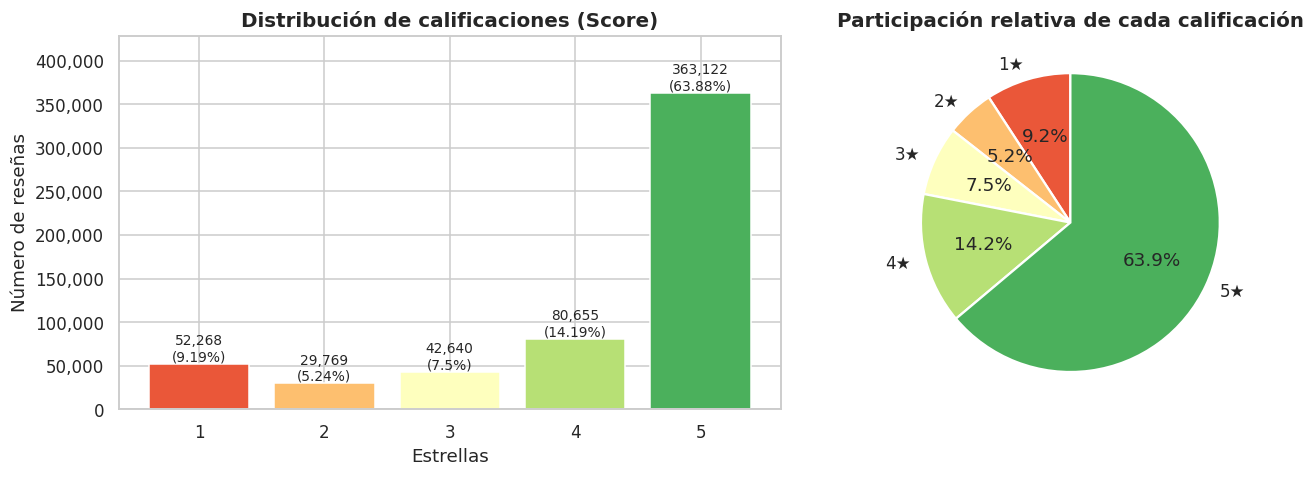

       Reseñas  Porcentaje_%
Score                       
1        52268          9.19
2        29769          5.24
3        42640          7.50
4        80655         14.19
5       363122         63.88


In [47]:
conteo_score = df_crudo["Score"].value_counts().sort_index()
porc_score = (conteo_score / len(df_crudo) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

barras = axes[0].bar(conteo_score.index.astype(str), conteo_score.values,
                     color=sns.color_palette("RdYlGn", 5))
axes[0].set_title("Distribución de calificaciones (Score)")
axes[0].set_xlabel("Estrellas")
axes[0].set_ylabel("Número de reseñas")
axes[0].yaxis.set_major_formatter(miles)
for b, v, p in zip(barras, conteo_score.values, porc_score.values):
    axes[0].text(b.get_x() + b.get_width()/2, v, f"{v:,}\n({p}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_ylim(0, conteo_score.max() * 1.18)

axes[1].pie(conteo_score.values, labels=[f"{i}★" for i in conteo_score.index],
            autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("RdYlGn", 5),
            wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[1].set_title("Participación relativa de cada calificación")

plt.tight_layout()
plt.show()

print(pd.DataFrame({"Reseñas": conteo_score, "Porcentaje_%": porc_score}))

In [48]:
df_exploracion = df_crudo.copy()
df_exploracion["Longitud_caracteres"] = df_exploracion["Text"].str.len()
df_exploracion["Longitud_palabras"] = df_exploracion["Text"].str.split().str.len()
df_exploracion["Longitud_summary"] = df_exploracion["Summary"].fillna("").str.split().str.len()
df_exploracion["Votos_utilidad"] = df_exploracion["HelpfulnessDenominator"]
df_exploracion["Ratio_utilidad"] = np.where(
    df_exploracion["HelpfulnessDenominator"] > 0,
    df_exploracion["HelpfulnessNumerator"] / df_exploracion["HelpfulnessDenominator"],
    np.nan
)
df_exploracion["Fecha"] = pd.to_datetime(df_exploracion["Time"], unit="s")
df_exploracion["Anio"] = df_exploracion["Fecha"].dt.year

resumen_numerico = df_exploracion[["Longitud_palabras", "Longitud_caracteres",
                  "Longitud_summary", "Votos_utilidad",
                  "Ratio_utilidad", "Score"]].describe().T
print(resumen_numerico.round(2))

                        count    mean     std   min    25%    50%    75%  \
Longitud_palabras    568454.0   80.26   79.46   3.0   33.0   56.0   98.0   
Longitud_caracteres  568454.0  436.22  445.34  12.0  179.0  302.0  527.0   
Longitud_summary     568454.0    4.11    2.60   0.0    2.0    4.0    5.0   
Votos_utilidad       568454.0    2.23    8.29   0.0    0.0    1.0    2.0   
Ratio_utilidad       298402.0    0.78    0.35   0.0    0.6    1.0    1.0   
Score                568454.0    4.18    1.31   1.0    4.0    5.0    5.0   

                         max  
Longitud_palabras     3432.0  
Longitud_caracteres  21409.0  
Longitud_summary        42.0  
Votos_utilidad         923.0  
Ratio_utilidad           3.0  
Score                    5.0  


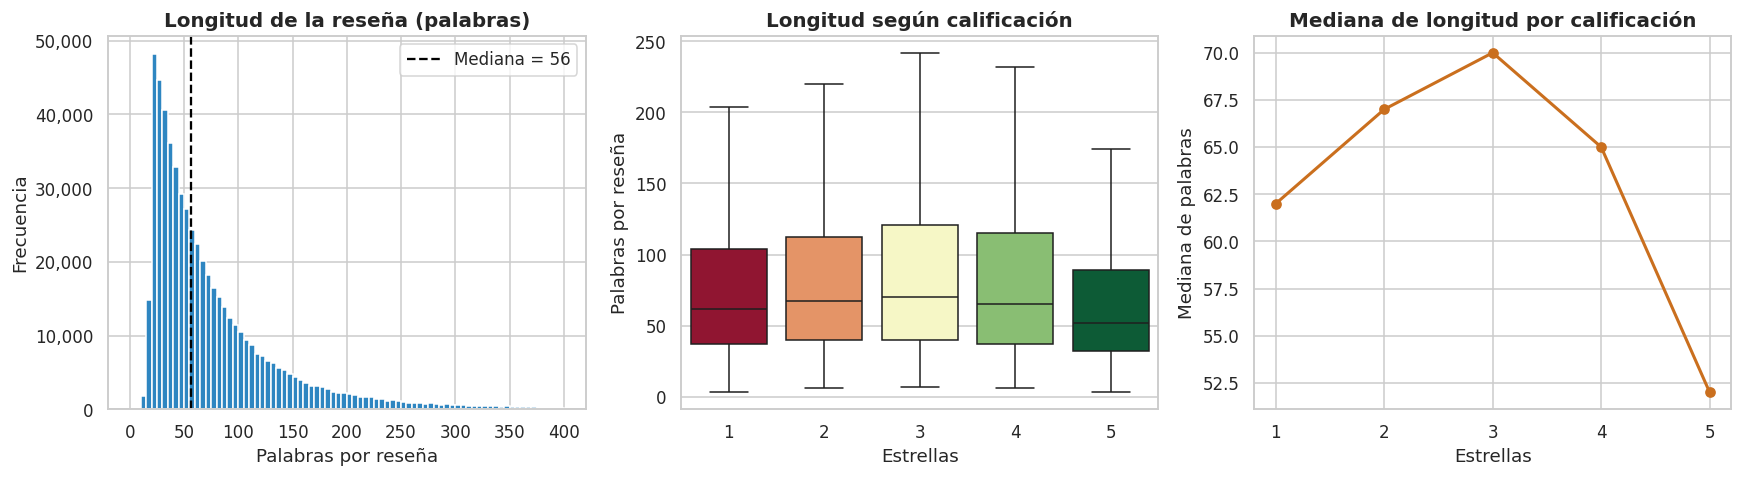

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(df_exploracion["Longitud_palabras"], bins=80, range=(0, 400),
             color=COLOR_BOW, edgecolor="white")
axes[0].axvline(df_exploracion["Longitud_palabras"].median(), color="black", ls="--",
                label=f"Mediana = {df_exploracion['Longitud_palabras'].median():.0f}")
axes[0].set_title("Longitud de la reseña (palabras)")
axes[0].set_xlabel("Palabras por reseña")
axes[0].set_ylabel("Frecuencia")
axes[0].yaxis.set_major_formatter(miles)
axes[0].legend()

sns.boxplot(data=df_exploracion, x="Score", y="Longitud_palabras",
            hue="Score", palette="RdYlGn", legend=False,
            showfliers=False, ax=axes[1])
axes[1].set_title("Longitud según calificación")
axes[1].set_xlabel("Estrellas")
axes[1].set_ylabel("Palabras por reseña")

medianas = df_exploracion.groupby("Score")["Longitud_palabras"].median()
axes[2].plot(medianas.index, medianas.values, marker="o", color=COLOR_TFIDF, lw=2)
axes[2].set_title("Mediana de longitud por calificación")
axes[2].set_xlabel("Estrellas")
axes[2].set_ylabel("Mediana de palabras")
axes[2].set_xticks(medianas.index)

plt.tight_layout()
plt.show()

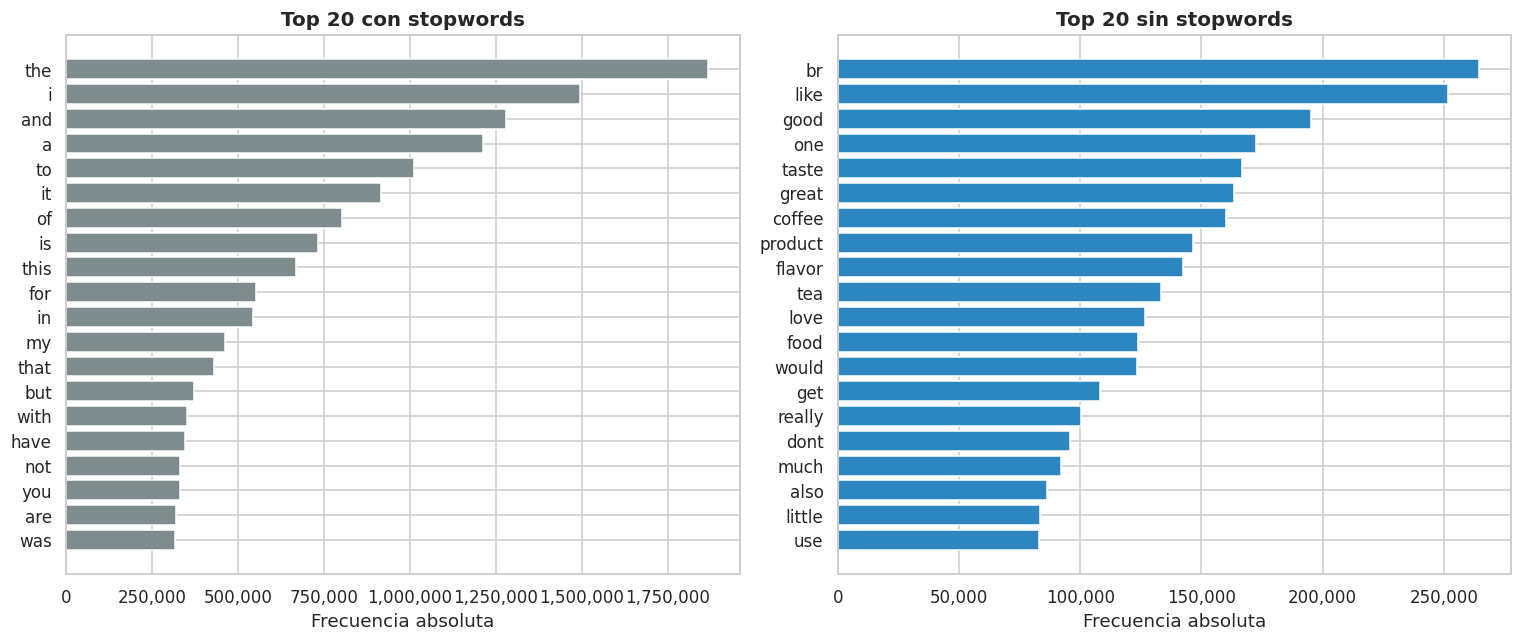

In [50]:
top_con = frecuencias.most_common(20)
top_sin = frecuencias_sin_stop.most_common(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, datos, titulo, color in [
    (axes[0], top_con, "Top 20 con stopwords", "#7F8C8D"),
    (axes[1], top_sin, "Top 20 sin stopwords", COLOR_BOW)
]:
    palabras = [p for p, _ in datos][::-1]
    valores = [c for _, c in datos][::-1]
    ax.barh(palabras, valores, color=color)
    ax.set_title(titulo)
    ax.set_xlabel("Frecuencia absoluta")
    ax.xaxis.set_major_formatter(miles)

plt.tight_layout()
plt.show()

In [51]:
df_corpus.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393892 entries, 0 to 568453
Data columns (total 3 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   Text            393892 non-null  object
 1   Score           393892 non-null  int64 
 2   Text_procesado  393892 non-null  object
dtypes: int64(1), object(2)
memory usage: 20.1+ MB


In [52]:
df_corpus.head()

,Text,Score,Text_procesado
0,I have bought several of the Vitality canned d...,5,bought several vitality canned dog food produc...
1,Product arrived labeled as Jumbo Salted Peanut...,1,product arrived labeled jumbo salted peanutsth...
2,This is a confection that has been around a fe...,4,confection around century light pillowy citrus...
3,If you are looking for the secret ingredient i...,2,looking secret ingredient robitussin believe f...
4,Great taffy at a great price. There was a wid...,5,great taffy great price wide assortment yummy ...


In [53]:
import pandas as pd

# Busca todas las variables activas que sean de tipo DataFrame
dataframes_encontrados = [
    var for var, obj in globals().items()
    if isinstance(obj, pd.DataFrame)
]

print("DataFrames encontrados en la sesión:")
for nombre_encontrado in dataframes_encontrados:
    print(f"- {nombre_encontrado} (Dimensiones: {globals()[nombre_encontrado].shape})")


DataFrames encontrados en la sesión:
- _ (Dimensiones: (5, 3))
- __ (Dimensiones: (2, 3))
- ___ (Dimensiones: (15, 3))
- df_crudo (Dimensiones: (568454, 10))
- _6 (Dimensiones: (5, 10))
- _8 (Dimensiones: (8, 5))
- df_limpio (Dimensiones: (393892, 10))
- df_corpus (Dimensiones: (393892, 3))
- muestra_bow (Dimensiones: (5, 10))
- _29 (Dimensiones: (5, 10))
- muestra_tfidf (Dimensiones: (5, 10))
- _31 (Dimensiones: (5, 10))
- comparacion (Dimensiones: (10, 3))
- _32 (Dimensiones: (10, 3))
- idf_df (Dimensiones: (5000, 2))
- _33 (Dimensiones: (15, 2))
- _34 (Dimensiones: (15, 2))
- comparacion_matrices (Dimensiones: (2, 5))
- _35 (Dimensiones: (2, 5))
- comparacion_documento (Dimensiones: (10, 3))
- _37 (Dimensiones: (10, 3))
- comparacion_terminos (Dimensiones: (15, 3))
- _38 (Dimensiones: (15, 3))
- df_modelo (Dimensiones: (364124, 4))
- resultados_modelos (Dimensiones: (2, 3))
- _45 (Dimensiones: (2, 3))
- df_exploracion (Dimensiones: (568454, 17))
- resumen_numerico (Dimensiones: (6, 

## Reflexión — Guion del Video (Actividad 3)

1. **Implementación:**
   Procesamos el dataset de Amazon Fine Food Reviews (568,454 documentos) limpiando etiquetas HTML, signos de puntuación y stopwords en inglés. Construimos matrices BoW y TF-IDF limitando el vocabulario a 5,000 términos.

2. **Aplicación en la Tarea:**
   Evaluamos ambas representaciones bajo las mismas condiciones utilizando un modelo de Regresión Logística para clasificación de sentimiento (positivas vs. negativas).

3. **Análisis Comparativo:**
   - **Dimensionalidad y Esparsidad:** Ambas matrices mantuvieron una densidad del 0.62% (99.38% de ceros).
   - **Pesos:** BoW asigna importancia según la repetición bruta ('like' y 'good' tienen frecuencias >190,000), mientras que TF-IDF penaliza estas palabras genéricas con un IDF bajo (~2.15) y resalta palabras específicas (como 'marmite' con IDF 9.46).
   - **Desempeño:** BoW obtuvo 92.91% de Accuracy y TF-IDF 92.89%, demostrando rendimientos equivalentes para clasificación global.

4. **Conclusiones Técnicas:**
   - **BoW** es preferible para clasificación rápida de sentimiento donde palabras clave frecuentes determinan la polaridad con menor costo computacional.
   - **TF-IDF** es mejor para búsqueda de información, recomendación o medición de similitud entre reseñas, al evitar que palabras comunes distorsionen la puntuación.